In [1]:
# Load libraries
import pandas as pd
import geopandas as gpd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.api as sm

sns.set_style('darkgrid')
import math
from sklearn.linear_model import LogisticRegression
from scipy import stats

import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

from license_model import LicenseModel

In [2]:
from imblearn.over_sampling import RandomOverSampler

In [3]:
# # Load toronto wards data
# wards = gpd.read_file('data/toronto_wards_and_neighbourhoods/wards.geojson')
# neighbourhoods = gpd.read_file('data/toronto_wards_and_neighbourhoods/neighbourhoods.geojson')

# # Map both plot
# fig, ax = plt.subplots(1, 2, figsize=(20, 10))
# wards.plot(ax=ax[0], color='lightgrey', edgecolor='black')
# neighbourhoods.plot(ax=ax[1], color='lightgrey', edgecolor='black')
# ax[0].set_title('Toronto Wards')
# ax[1].set_title('Toronto Neighbourhoods')
# plt.tight_layout()
# plt.show()

# 1.0 Setup and run the model

### 1.1 Setup

In [145]:
# INPUT VARIABLES

CITY = 'Toronto'
INPUT_FILE = os.path.join('data', 'complete_city_data', 'toronto_inside_airbnb_data', 'may_3_2025.csv')
MIN_NIGHTS_FOR_LICENSE = 28
LICENSE_REGEX_PATTERN = r'^STR-\d{4}-[A-Za-z]{6}$'

In [146]:
city_model = LicenseModel(
    input_file=INPUT_FILE,
    city=CITY,
    min_nights_for_license=MIN_NIGHTS_FOR_LICENSE,
    license_regex_pattern=LICENSE_REGEX_PATTERN
)

In [147]:
city_model.load_data()
city_model.preprocess_data(print_info=True)

Columns with constant values: []


In [148]:
city_model.create_legal_listing_column(print_info=False)
city_model.remove_columns_with_many_nan_values(maintain_columns=['price', 'bedrooms', 'bathrooms'])
city_model.transform_object_columns()
city_model.remove_low_variance_columns(print_info=True)
city_model.remove_missing_values(print_info=True)
# city_model.listings_df.drop(columns=['neighbourhood_cleansed'], inplace=True)
city_model.one_hot_encode_columns(print_info=True)
city_model.remove_separation(print_info=True)
city_model.detect_and_remove_multicollinearity(print_info=False)

Removed columns with more than 5.0% missing values: ['beds', 'estimated_revenue_l365d', 'host_response_rate', 'host_response_time', 'review_scores_accuracy', 'review_scores_checkin', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_rating', 'review_scores_value', 'reviews_per_month']
Removed low variance columns: ['host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'calculated_host_listings_count_shared_rooms']
Dropped categories:
neighbourhood_cleansed : Agincourt North
room_type : Entire home/apt
Problematic columns causing separation: []


### 1.2 Check assumptions

In [149]:
violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds()
print("Significant variables (p < 0.05) that violate linearity assumption:")
print(violating_vars)

Significant variables (p < 0.05) that violate linearity assumption:
['number_of_reviews_ly']


In [150]:
delete_instead_of_transform = True  # Set to True if you want to delete the violating variables instead of transforming them

if delete_instead_of_transform:
    # If we are deleting the violating variables, we will remove them from the DataFrame
    for var in violating_vars:
        print(f"Deleting variable: {var}")
        city_model.listings_df.drop(columns=[var], inplace=True)
else:
    print("Transforming variables to resolve linearity issues...")

    # Test multiple transformations for each violating variable
    for var in violating_vars:
        print("_" * 50)
        # Make a clean copy of the original data
        listings_data_temp = city_model.listings_df.copy()

        print(f"Testing transformations for variable: {var}")

        # Define a list of transformations to try
        transformations = {
            "log": lambda x: np.log1p(x),  # log(1 + x), handles zero values
            "sqrt": lambda x: np.sqrt(x),  # square root
            "reciprocal": lambda x: 1 / (x + 1e-6),  # reciprocal, avoids division by zero
            "square": lambda x: x**2,  # square
            "cube": lambda x: x**3,  # cube
            "exp": lambda x: np.exp(x),  # exponential
            "inverse_sqrt": lambda x: 1 / (np.sqrt(x) + 1e-6),  # inverse square root
            "log10": lambda x: np.log10(x + 1e-6),  # base-10 logarithm
            "log2": lambda x: np.log2(x + 1e-6),  # base-2 logarithm
            "zscore": lambda x: (x - np.mean(x)) / np.std(x),  # z-score normalization
            "minmax": lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)),  # min-max scaling
            "sigmoid": lambda x: 1 / (1 + np.exp(-x)),  # sigmoid transformation
            "tanh": lambda x: np.tanh(x),  # hyperbolic tangent
            "arcsinh": lambda x: np.arcsinh(x),  # inverse hyperbolic sine
            "cbrt": lambda x: np.cbrt(x),  # cube root
            "abs": lambda x: np.abs(x),  # absolute value
            "clip": lambda x: np.clip(x, 0, np.percentile(x, 95)),  # clip outliers at 95th percentile
            "rank": lambda x: x.rank(method="average"),  # rank transformation
            "binarize": lambda x: (x > np.median(x)).astype(int),  # binarize based on median
        }

        # Try each transformation
        for name, transform in transformations.items():
            try:
                # Apply the transformation
                transformed_var = transform(listings_data_temp[var])
                listings_data_temp[var] = transformed_var

                # Re-check linearity with the transformed variable
                new_violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds(
                    df_city_1=listings_data_temp
                )

                if var not in new_violating_vars:
                    print(f"Transformation '{name}' resolved linearity issue for {var}.")

                    # Update the model with the transformed variable
                    city_model.listings_df[f"{var}_{name}"] = transformed_var
                    city_model.listings_df.drop(columns=[var], inplace=True)
                    
                    break  # Stop testing further transformations for this variable
                else:
                    # print(f"Transformation '{name}' did not resolve linearity issue for {var}.")
                    pass
            except Exception as e:
                print(f"Error applying transformation '{name}' to {var}: {e}")

        else:
            # If no transformation resolved the issue
            print(f"No transformation resolved the linearity issue for {var}.")

Deleting variable: number_of_reviews_ly


Optimization terminated successfully.
         Current function value: 0.164499
         Iterations: 387
         Function evaluations: 397
         Gradient evaluations: 393
Threshold for Cook Distance = 0.0006938421509106678
Number of influential outliers: 87
Percentage of influential outliers: 1.5%


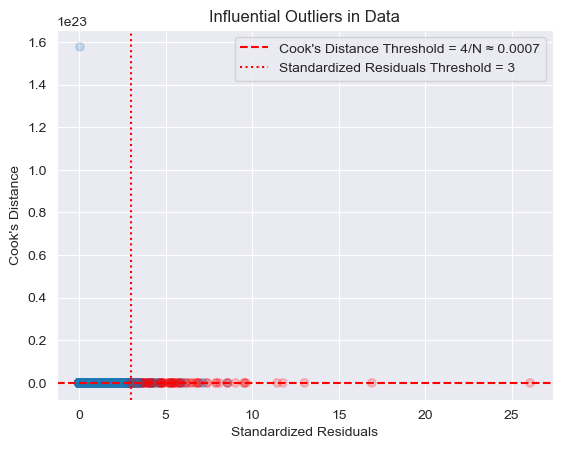

In [151]:
city_model.check_no_strongly_influential_outliers(print_info=True, show_plot=True, remove_hi_outliers=True)

## TEST OTHER MODEL TRAINING

In [11]:
from copy import deepcopy
from logit_model_class import LogitModel
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

In [134]:
from imblearn.over_sampling import SMOTE, ADASYN, SMOTENC
from imblearn.combine import SMOTEENN, SMOTETomek

In [159]:
# Make a copy
city_model_copy = deepcopy(city_model)

In [160]:
city_model_copy.logit_model = LogitModel(target_column='legal_listing', test_size=0.2, random_state=42)
city_model_copy.logit_model.prepare_data(data=city_model_copy.listings_df)

In [161]:
categorical_columns = ['host_is_superhost', 'instant_bookable', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

# Add to categorical columns all columns in city_model_copy.listings_df that begin with 'neighbourhood_cleansed_'
categorical_columns += [col for col in city_model_copy.listings_df.columns if col.startswith('neighbourhood_cleansed_')]

In [162]:
ros = RandomOverSampler(random_state=42)
sme = SMOTEENN(random_state=42)
smt = SMOTETomek(random_state=42)

# X_resampled, y_resampled = ros.fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = SMOTE().fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = ADASYN().fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
X_resampled, y_resampled = SMOTENC(categorical_features=categorical_columns).fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = sme.fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = smt.fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)

city_model_copy.logit_model.X_train = X_resampled
city_model_copy.logit_model.y_train = y_resampled

In [18]:
weights = city_model_copy.logit_model.y_train.map({0:10, 1:1})

In [163]:
city_model_copy.logit_model.model = sm.Logit(city_model_copy.logit_model.y_train, city_model_copy.logit_model.X_train)
# city_model_copy.logit_model.result = city_model_copy.logit_model.model.fit(weights=weights, method='bfgs', maxiter=1000)
city_model_copy.logit_model.result = city_model_copy.logit_model.model.fit(method='bfgs', maxiter=1000)

Optimization terminated successfully.
         Current function value: 0.178247
         Iterations: 410
         Function evaluations: 422
         Gradient evaluations: 418


In [167]:
city_model_copy.evaluate_model(selected_threshold=0.5)

Accuracy: 0.8882
Confusion Matrix:
[[ 37  30]
 [ 97 972]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.28      0.55      0.37        67
         1.0       0.97      0.91      0.94      1069

    accuracy                           0.89      1136
   macro avg       0.62      0.73      0.65      1136
weighted avg       0.93      0.89      0.91      1136



In [158]:
city_model_copy.does_data_follow_one_in_ten_rule()

Number of events (legal/illegal listings): 293
Maximum number of predictors allowed (one-in-ten rule): 29
Number of predictors in the model: 158


False

### 1.3 Run Model

In [61]:
city_model.train_model()

Optimization terminated successfully.
         Current function value: 0.097122
         Iterations: 112
         Function evaluations: 130
         Gradient evaluations: 127
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 4482
Model:                          Logit   Df Residuals:                     4462
Method:                           MLE   Df Model:                           19
Date:                Fri, 06 Jun 2025   Pseudo R-squ.:                  0.3783
Time:                        00:55:06   Log-Likelihood:                -435.30
converged:                       True   LL-Null:                       -700.19
Covariance Type:            nonrobust   LLR p-value:                3.108e-100
                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [78]:
city_model.evaluate_model(selected_threshold=0.85)

Accuracy: 0.9465
Confusion Matrix:
[[  30   23]
 [  37 1031]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.45      0.57      0.50        53
         1.0       0.98      0.97      0.97      1068

    accuracy                           0.95      1121
   macro avg       0.71      0.77      0.74      1121
weighted avg       0.95      0.95      0.95      1121



In [79]:
city_model.does_data_follow_one_in_ten_rule()

Number of events (legal/illegal listings): 216
Maximum number of predictors allowed (one-in-ten rule): 21
Number of predictors in the model: 20
The model follows the one-in-ten rule.


True

In [83]:
# From city_model.logit_model.result, export the coefficients
coefficients = city_model.logit_model.result.params
coefficients

host_acceptance_rate                             0.021612
host_is_superhost                               -0.737391
host_total_listings_count                       -0.018445
accommodates                                     0.056299
bathrooms                                        0.499223
bedrooms                                        -0.509459
price                                            0.000122
minimum_nights                                   0.307121
availability_30                                 -0.028389
availability_90                                  0.014737
availability_365                                -0.000711
number_of_reviews                               -0.000593
number_of_reviews_l30d                          -0.150226
estimated_occupancy_l365d                        0.025689
instant_bookable                                -0.578319
calculated_host_listings_count_entire_homes     -0.320540
calculated_host_listings_count_private_rooms    -0.098510
room_type_Hote

# AUTOMATED CODE FOR EVERY MONTH

In [2]:
# Set up the empty DataFrame for coefficients
coefficients_df = pd.DataFrame()

In [3]:
CITY = 'Toronto'
# INPUT_FILE = os.path.join('data', 'complete_city_data', 'toronto_inside_airbnb_data', 'may_3_2025.csv')
MIN_NIGHTS_FOR_LICENSE = 28
LICENSE_REGEX_PATTERN = r'^STR-\d{4}-[A-Za-z]{6}$'

In [4]:
# Loop through every file in the data/complete_city_data/toronto_inside_airbnb_data/ directory

i = 0

for filename in os.listdir('data/complete_city_data/toronto_inside_airbnb_data/'):
    # i += 1
    # if i > 3:
    #     break

    if filename.endswith('.csv'):
        file_path = os.path.join('data', 'complete_city_data', 'toronto_inside_airbnb_data', filename)
        print(f"Processing file: {file_path}")

        city_model = LicenseModel(
            input_file=file_path,
            city=CITY,
            min_nights_for_license=MIN_NIGHTS_FOR_LICENSE,
            license_regex_pattern=LICENSE_REGEX_PATTERN
        )

        # Load the data
        city_model.load_data()
        city_model.preprocess_data(print_info=False)

        # Create legal listing column
        city_model.create_legal_listing_column(print_info=False)

        # Remove columns with many NaN values
        city_model.remove_columns_with_many_nan_values(maintain_columns=['price', 'bedrooms', 'bathrooms'], print_info=False)

        # Transform object columns
        city_model.transform_object_columns()

        # Remove low variance columns
        city_model.remove_low_variance_columns(print_info=False)

        # Remove missing values
        city_model.remove_missing_values(print_info=False)

        city_model.listings_df.drop(columns=['neighbourhood_cleansed'], inplace=True)

        # One-hot encode columns
        city_model.one_hot_encode_columns(print_info=False)

        # Remove separation
        city_model.remove_separation(print_info=False)
        
        # Detect and remove multicollinearity
        city_model.detect_and_remove_multicollinearity(print_info=False)

        # Remove violating variables
        violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds()
        for var in violating_vars:
            # If price is one of the violating variables, we will not delete it
            if var == 'price':
                continue
            city_model.listings_df.drop(columns=[var], inplace=True)

        city_model.check_no_strongly_influential_outliers(print_info=False, show_plot=False, remove_hi_outliers=True)

        # Train the model
        city_model.train_model()

        # Evaluate the model
        city_model.evaluate_model(selected_threshold=0.85)

        # Get the coefficients
        coefficients = city_model.logit_model.result.params
        coefficients_df[filename] = coefficients
    
    # Delete the model to free up memory
    del city_model.logit_model
    del city_model.listings_df
    del city_model


Processing file: data\complete_city_data\toronto_inside_airbnb_data\april_7_2025.csv
Optimization terminated successfully.
         Current function value: 0.197448
         Iterations: 123
         Function evaluations: 142
         Gradient evaluations: 135
Optimization terminated successfully.
         Current function value: 0.097035
         Iterations: 131
         Function evaluations: 142
         Gradient evaluations: 139
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 4548
Model:                          Logit   Df Residuals:                     4530
Method:                           MLE   Df Model:                           17
Date:                Thu, 05 Jun 2025   Pseudo R-squ.:                  0.3971
Time:                        14:45:42   Log-Likelihood:                -441.31
converged:                       True   LL-Null:                       -732.00
Covariance T

In [5]:
coefficients_df

,april_7_2025.csv,august_7_2024.csv,december_8_2024.csv,february_9_2025.csv,january_9_2025.csv,july_12_2024.csv,june_10_2024.csv,march_2_2025.csv,may_3_2025.csv,november_7_2024.csv,october_5_2024.csv,september_5_2024.csv
host_acceptance_rate,0.017999,0.006620,NaN,NaN,NaN,NaN,0.016327,0.018999,0.021612,0.019522,0.017565,NaN
host_is_superhost,-0.601781,-0.419794,0.007180,-1.082734,-0.190063,0.092624,-0.330240,-1.447576,-0.737391,-0.061677,-0.173640,0.327721
bathrooms,0.804957,0.564057,0.558880,NaN,NaN,0.697715,0.613886,0.844467,0.499223,0.574433,0.512731,1.073095
bedrooms,-0.683412,-0.319080,-0.361962,0.011209,-0.017445,-0.311793,-0.279444,-0.752853,-0.509459,-0.523230,-0.245914,-0.180664
price,0.002514,0.000660,0.000156,NaN,NaN,0.000358,0.000649,0.001889,0.000122,0.000080,-0.000097,0.001980
minimum_nights,0.073978,0.043410,0.219002,0.404359,0.475344,0.237409,0.157305,0.192424,0.307121,0.186911,0.089252,0.100929
availability_30,-0.078495,-0.006243,-0.001513,-0.027160,-0.022401,0.018968,0.001867,-0.013179,-0.028389,-0.005866,-0.039093,-0.050875
availability_90,0.026422,-0.008769,0.013023,0.018162,0.019322,-0.000332,0.000768,0.007914,0.014737,0.004783,0.011543,0.023099
availability_365,0.000299,0.003496,0.000141,0.001038,0.001673,0.002938,0.001333,-0.000297,-0.000711,-0.000212,0.001538,0.001118
number_of_reviews,-0.001541,0.014153,0.016809,0.001243,0.040600,0.005404,0.014784,-0.000582,-0.000593,0.014619,0.016988,0.011869


In [109]:
# For each column, rename to remove the .csv extension
coefficients_df.columns = [re.sub(r'\.csv$', '', col) for col in coefficients_df.columns]

In [124]:
# Make a copy 
coefficients_df_copy = coefficients_df.copy()

In [131]:
# Each column name is in the format "month_day_year". The month is by full name, the day is a number, and the year is a four-digit number. Reorder the columns to be in chronological order
coefficients_df_copy = coefficients_df.copy()
# Start by removing underscores
coefficients_df_copy.columns = [re.sub(r'_', ' ', col) for col in coefficients_df_copy.columns]

# Now convert the month names to numbers
month_mapping = {
    'january': '01',
    'february': '02',
    'march': '03',
    'april': '04',
    'may': '05',
    'june': '06',
    'july': '07',
    'august': '08',
    'september': '09',
    'october': '10',
    'november': '11',
    'december': '12'
}
def convert_month_name_to_number(month_name):
    month_name = month_name.lower()
    return month_mapping.get(month_name, month_name)
coefficients_df_copy.columns = [
    re.sub(r'(\w+)\s(\d{1,2})\s(\d{4})', lambda m: f"{convert_month_name_to_number(m.group(1))} {m.group(2)} {m.group(3)}", col)
    for col in coefficients_df_copy.columns
]

# Now convert to year-month-day format
coefficients_df_copy.columns = [
    re.sub(r'(\d{2})\s(\d{1,2})\s(\d{4})', lambda m: f"{m.group(3)}-{int(m.group(1)):02d}-{int(m.group(2)):02d}", col)
    for col in coefficients_df_copy.columns
]

# Change day to two digits
coefficients_df_copy.columns = [
    re.sub(r'(\d{1,2})-(\d{1,2})-(\d{4})', lambda m: f"{int(m.group(1)):02d}-{int(m.group(2)):02d}-{m.group(3)}", col)
    for col in coefficients_df_copy.columns
]

# Now sort the columns
coefficients_df_copy = coefficients_df_copy.reindex(sorted(coefficients_df_copy.columns), axis=1)

In [137]:
coefficients_df_copy

,2024-06-10,2024-07-12,2024-08-07,2024-09-05,2024-10-05,2024-11-07,2024-12-08,2025-01-09,2025-02-09,2025-03-02,2025-04-07,2025-05-03
host_acceptance_rate,0.018018,0.015951,0.003308,0.017905,0.019478,0.015547,0.016167,0.020959,0.018901,0.019762,0.020292,0.019881
host_is_superhost,-0.048834,-0.205287,-0.186373,0.022533,-0.288232,-0.248164,-0.190506,-0.477881,-0.582392,-0.715130,-0.280938,-0.224472
host_listings_count,NaN,NaN,NaN,NaN,-0.017207,NaN,NaN,NaN,NaN,NaN,0.012792,NaN
accommodates,-0.053863,-0.102712,-0.115961,-0.083733,-0.072391,-0.010680,-0.037348,0.004369,-0.009017,-0.036202,-0.073207,0.020577
bathrooms,0.403579,0.491721,0.356036,0.327144,0.405497,0.433669,0.405916,NaN,NaN,0.338255,0.436665,0.235484
bedrooms,-0.262920,-0.276421,-0.196249,-0.230845,-0.161400,-0.288219,-0.340529,-0.177752,-0.092684,-0.350495,-0.335644,-0.274344
price,0.000526,0.001310,0.000688,0.001385,0.000406,0.000104,0.000136,NaN,NaN,0.001437,0.001950,0.000352
minimum_nights,0.088138,0.127827,0.032934,0.056342,0.084148,0.153117,0.159644,0.167556,0.133555,0.118459,0.059766,0.128158
availability_30,0.001044,0.010532,-0.008273,-0.033884,-0.015787,-0.000968,-0.008834,-0.009254,-0.010405,-0.004475,-0.028507,-0.013049
availability_90,0.000234,-0.002674,-0.003244,0.010455,0.005113,0.004888,0.007178,0.007277,0.008018,0.004943,0.010044,0.005517


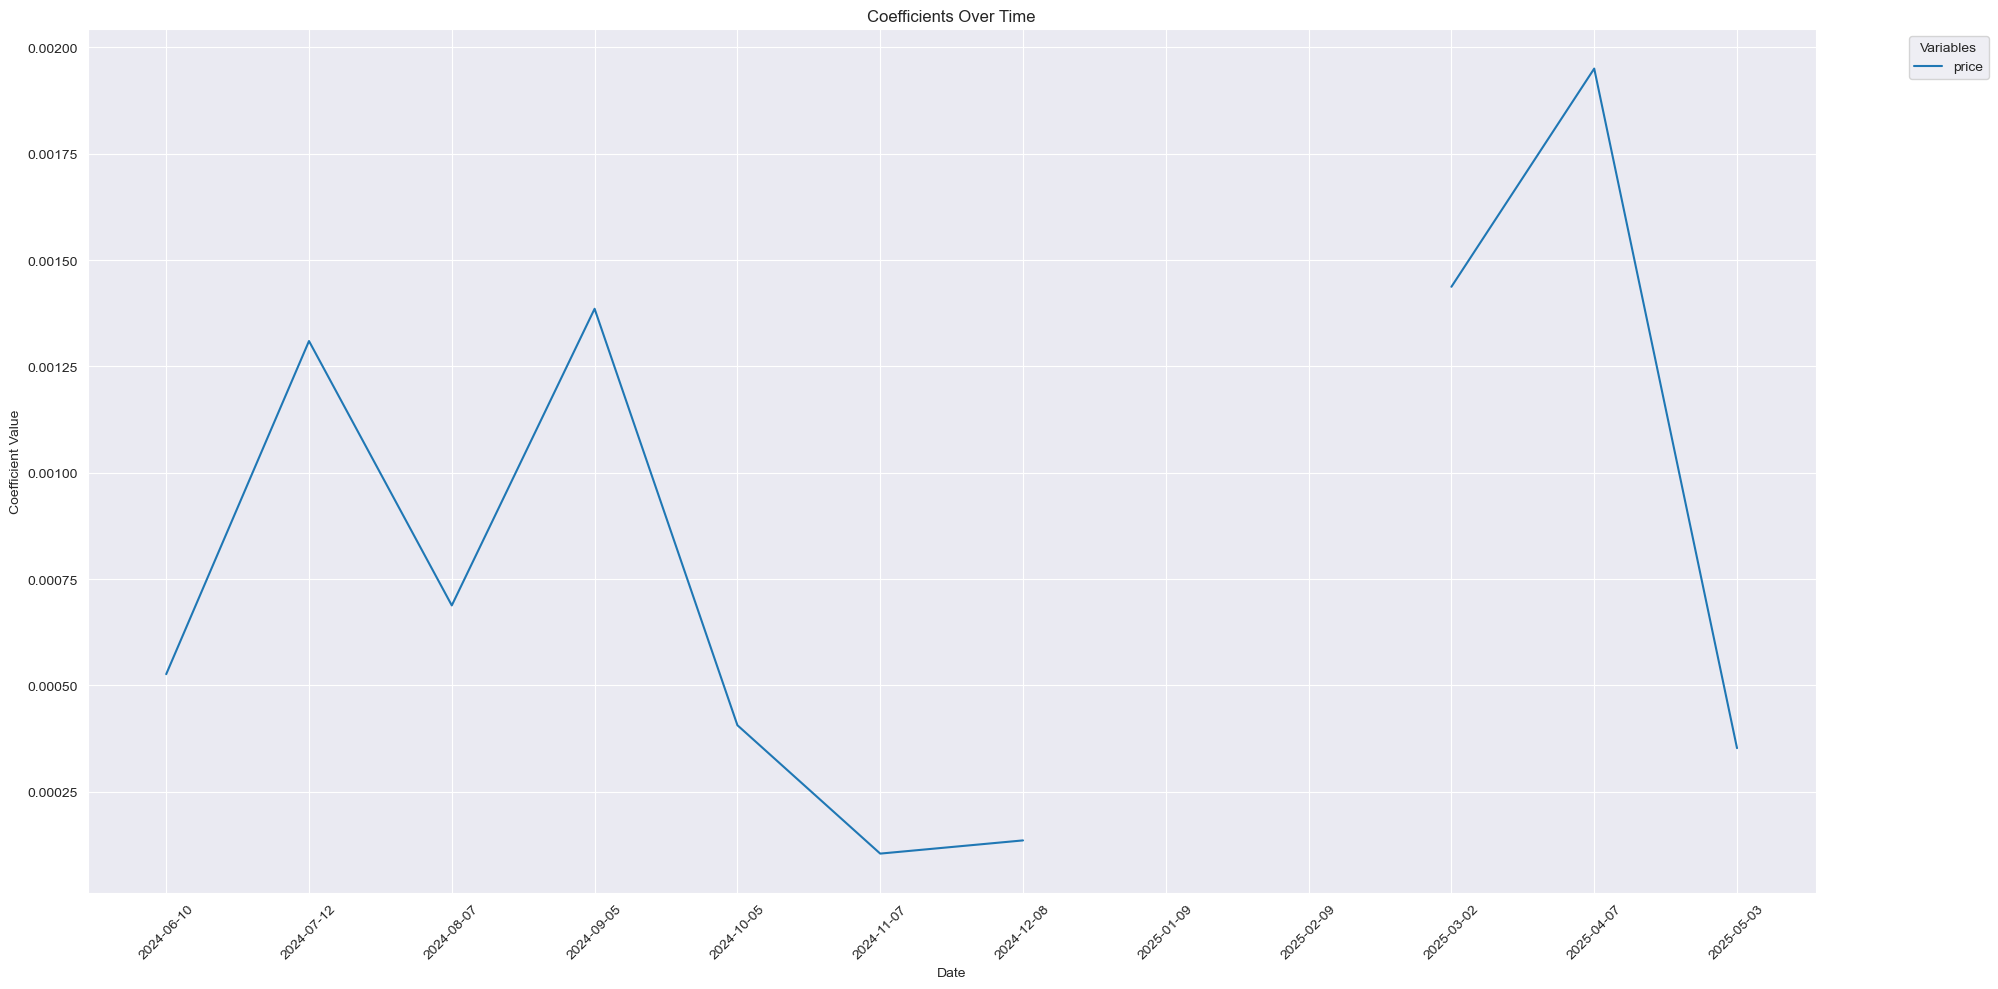

In [140]:
# Plot the coefficients in a line plot (columns are dates, so the x-axis is the columns, and the y-axis is the coefficients) Colour each line by the row
# Plot only the coefficients for "price", "bedrooms", and "bathrooms"
plt.figure(figsize=(20, 10))
for index, row in coefficients_df_copy.iterrows():
    if index in ["price"]:
        plt.plot(coefficients_df_copy.columns, row, label=index)
plt.title('Coefficients Over Time')
plt.xlabel('Date')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.legend(title='Variables', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [138]:
# Save the coefficients DataFrame to a CSV file
coefficients_df_copy.to_csv('data/toronto_airbnb_coefficients.csv', index=True)